# 📊 Exploratory Data Analysis (EDA) Plan

*Statistical Characterization of the PTB-XL Dataset*

---

## 🎯 Objectives of EDA

The purpose of EDA is to:

1. Understand population characteristics
2. Quantify label distribution and imbalance
3. Assess signal properties
4. Identify potential sources of bias
5. Inform modeling and validation strategy

EDA is not visualization for aesthetics — it is **pre-model statistical reconnaissance**.

---

# 1️⃣ Cohort Characterization

## 1.1 Sample Size

* Total number of ECG recordings
* Total number of unique patients
* Recordings per patient distribution

**Why it matters:**
Prevents patient-level data leakage and informs split strategy.

---

## 1.2 Demographics

### Age

* Mean ± SD
* Median (IQR)
* Histogram
* Age bins (e.g., <40, 40–60, >60)

### Sex

* Counts and percentages
* Bar plot

**Why it matters:**
Enables subgroup analysis and bias assessment.

---

# 2️⃣ Label Distribution Analysis

PTB-XL is multi-label.

## 2.1 Diagnostic Superclasses

Compute:

* Count per class
* Prevalence (%)
* Co-occurrence matrix

Display:

* Bar plot of class frequencies
* Heatmap of label co-occurrence

**Why it matters:**

* Detects severe imbalance
* Guides weighted loss design
* Informs macro vs micro metric choice

---

## 2.2 Label Cardinality

* Average number of labels per ECG
* Distribution of label counts

This tells you:

* How multi-label the dataset actually is

---

# 3️⃣ Signal-Level Analysis

(Using 500 Hz or 100 Hz data)

## 3.1 Signal Length

* Confirm uniform length
* Check for missing or corrupted files

## 3.2 Amplitude Distribution

* Mean amplitude per lead
* Standard deviation per lead
* Outlier detection

## 3.3 Lead Correlation

* Correlation matrix between leads
* Detect redundancy or abnormal signals

---

# 4️⃣ Missingness Analysis

* Missing demographic data
* Missing labels
* Missing signals

If present:

* Quantify proportion
* Determine missingness pattern (MCAR/MAR suspicion)

---

# 5️⃣ Train/Test Split Validation

Before training:

* Confirm patient-level split
* Compare:

  * Age distribution (train vs test)
  * Sex distribution
  * Label prevalence

Use:

* t-test or Mann–Whitney (age)
* Chi-square test (sex, labels)

**Goal:** Ensure no distributional shift between splits.

---

# 6️⃣ Class Imbalance Quantification

Compute:

* Imbalance ratio (max/min class frequency)
* Effective number of samples (for weighted loss)

Decide:

* Class weights
* Focal loss?
* Threshold tuning strategy?

---

# 7️⃣ Correlation Between Demographics and Labels

Example analyses:

* Age vs MI prevalence
* Sex vs conduction disorders

Use:

* Logistic regression (univariate)
* Odds ratios with 95% CI

This gives you publishable-level descriptive stats.

---

# 📈 Key Tables to Produce

| Table   | Description                           |
| ------- | ------------------------------------- |
| Table 1 | Baseline Demographics                 |
| Table 2 | Diagnostic Class Prevalence           |
| Table 3 | Label Co-occurrence Matrix            |
| Table 4 | Train vs Test Distribution Comparison |

---

# 🧠 Statistical Framing

EDA is answering:

* Is the dataset representative?
* Is it balanced?
* Is it suitable for macro-AUC evaluation?
* Are there confounders?
* Will subgroup analysis be powered?

---

# 🚨 Red Flags to Look For

* Extreme class imbalance (<1%)
* One sex dominating a diagnostic label
* Age skew in test set
* Highly correlated labels
* Duplicate patients across splits

In [1]:
# --------------------------------------------------
# Importing necessary libraries
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast

## 2️⃣ Load the Data

In [2]:
# --------------------------------------------------
# Setting up paths
# --------------------------------------------------
file_path = "../data/ptbxl_database.csv"
df = pd.read_csv(file_path, sep=",")

# print basic info about the dataframe
print(df.info())
print(df.describe())
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21799 entries, 0 to 21798
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ecg_id                        21799 non-null  int64  
 1   patient_id                    21799 non-null  float64
 2   age                           21799 non-null  float64
 3   sex                           21799 non-null  int64  
 4   height                        6974 non-null   float64
 5   weight                        9421 non-null   float64
 6   nurse                         20326 non-null  float64
 7   site                          21782 non-null  float64
 8   device                        21799 non-null  object 
 9   recording_date                21799 non-null  object 
 10  report                        21799 non-null  object 
 11  scp_codes                     21799 non-null  object 
 12  heart_axis                    13331 non-null  object 
 13  i

In [3]:
df.head()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


## 3️⃣ Basic Cohort Stats

In [4]:
# --------------------------------------------------
# Basic statistics about the dataset
n_records = len(df)
n_patients = df["patient_id"].nunique()

print(f"Total ECG recordings: {n_records}")
print(f"Unique patients: {n_patients}")
print(f"Average recordings per patient: {n_records / n_patients:.2f}")

Total ECG recordings: 21799
Unique patients: 18869
Average recordings per patient: 1.16


## 4️⃣ Demographics 

count    21799.000000
mean        62.769301
std         32.308813
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64


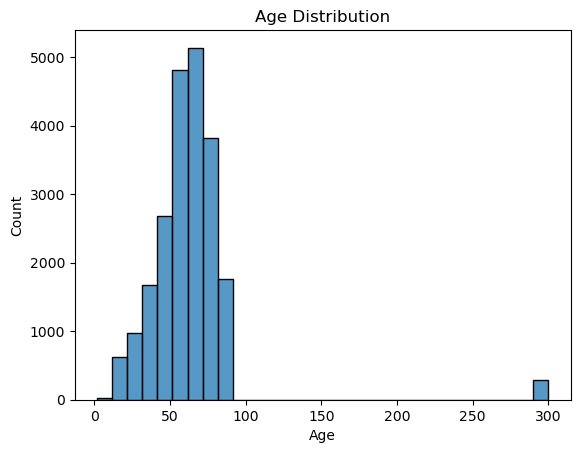

In [5]:
# --------------------------------------------------
# Age Distribution
# --------------------------------------------------
print(df["age"].describe())

plt.figure()
sns.histplot(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

According to the changelog.txt people above 89 years old are stored as '300' for provacy reasons. All we know is that they are above 89 years old.

In [6]:
# Can correct the age of 300 to a more reasonable value such as 90 since there at least 89 years old patients in the dataset. 
df["age_clean"] = df["age"].apply(lambda x: 90 if x == 300 else x)

In [7]:
# ----------------------------
# Basic Counts
# ----------------------------
n_records = len(df)
n_patients = df["patient_id"].nunique()

# ----------------------------
# Age Statistics
# ----------------------------
age_mean = df["age_clean"].mean()
age_sd = df["age_clean"].std()
age_median = df["age_clean"].median()
age_q1 = df["age_clean"].quantile(0.25)
age_q3 = df["age_clean"].quantile(0.75)

# ----------------------------
# Sex Distribution
# ----------------------------
sex_counts = df["sex"].value_counts()
sex_percent = df["sex"].value_counts(normalize=True) * 100

sex_label
Male      11354
Female    10445
Name: count, dtype: int64
sex_label
Male      52.084958
Female    47.915042
Name: proportion, dtype: float64


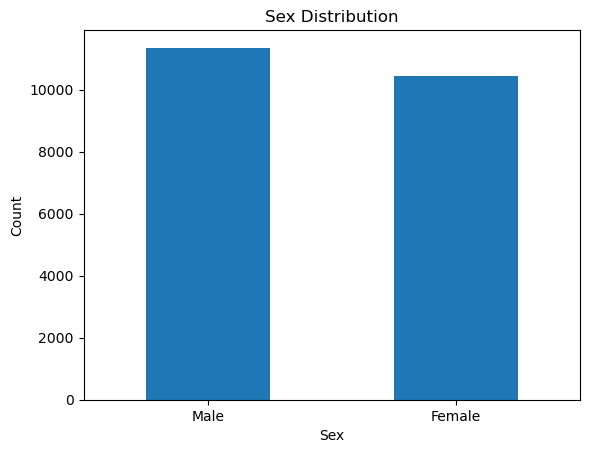

In [8]:
# --------------------------------------------------
# Sex Distribution
# --------------------------------------------------

# Create the sex column into labels 
sex_map = {
    0: "Male",
    1: "Female"
}

df["sex_label"] = df["sex"].map(sex_map)
df["sex_label"] = pd.Categorical(
    df["sex_label"],
    categories=["Male", "Female"]
)

sex_counts = df["sex_label"].value_counts().reindex(["Male", "Female"])
sex_percent = df["sex_label"].value_counts(normalize=True).reindex(["Male", "Female"]) * 100

print(sex_counts)
print(sex_percent)

# PLot the sex distribution as a bar chart
plt.figure()
sex_counts.plot(kind="bar")
plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# 5️⃣ Diagnostic Labels

In [9]:
# The 'scp_codes' column contains string representations of dictionaries. We need to convert them to actual dictionaries for analysis.
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

# Load the mapping file for SCP codes to their descriptions
scp_file = "../data/scp_statements.csv"
scp_statements = pd.read_csv(scp_file)
print(scp_statements.columns) # Check the columns in the scp_statements dataframe

# Fix the first column name which should be our scp_code
scp_statements = scp_statements.rename(columns={scp_statements.columns[0]: "scp_code"})
print(scp_statements.columns) # Check the columns again to confirm the rename

Index(['Unnamed: 0', 'description', 'diagnostic', 'form', 'rhythm',
       'diagnostic_class', 'diagnostic_subclass', 'Statement Category',
       'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code',
       'DICOM Code'],
      dtype='object')
Index(['scp_code', 'description', 'diagnostic', 'form', 'rhythm',
       'diagnostic_class', 'diagnostic_subclass', 'Statement Category',
       'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code',
       'DICOM Code'],
      dtype='object')


In [10]:
# Keep only diagnostic classes/codes
scp_diag = scp_statements[scp_statements["diagnostic"] == 1]

# Create mapping from code to superclass (scp_code to diagnostic_class)
code_to_superclass = dict(
    zip(scp_diag["scp_code"], scp_diag["diagnostic_class"])
)
print("Example mapping:")
print(list(code_to_superclass.items())[:10])

Example mapping:
[('NDT', 'STTC'), ('NST_', 'STTC'), ('DIG', 'STTC'), ('LNGQT', 'STTC'), ('NORM', 'NORM'), ('IMI', 'MI'), ('ASMI', 'MI'), ('LVH', 'HYP'), ('LAFB', 'CD'), ('ISC_', 'STTC')]


In [11]:
# Develop a helper fuction to extract superclasses from the scp_codes 
def extract_superclasses(scp_dict):
    """
    Extracts superclass labels from a dictionary of SCP codes.
    """
    classes = set()
    for code in scp_dict.keys():
        if code in code_to_superclass:
            classes.add(code_to_superclass[code])
    return list(classes)

df["superclasses"] = df["scp_codes"].apply(extract_superclasses)

In [12]:
# ---------------------------------------------------
# Sanity Checks on the extracted superclasses
# ---------------------------------------------------

# Check how many ECGs have at least one diagnostic label
n_with_labels = (df["superclasses"].apply(len) > 0).sum()
n_total = len(df)

print(f"ECGs with diagnostic labels: {n_with_labels}/{n_total}")
print(f"Percentage labeled: {100 * n_with_labels / n_total:.2f}%")

# Check for empty labels
empty_labels = df[df["superclasses"].apply(len) == 0]
print("Number of ECGs with NO diagnostic superclass:", len(empty_labels))

ECGs with diagnostic labels: 21388/21799
Percentage labeled: 98.11%
Number of ECGs with NO diagnostic superclass: 411


In [13]:
# Count the occurrences of each superclass
all_classes = [cls for sublist in df["superclasses"] for cls in sublist]
class_counts = pd.Series(all_classes).value_counts()

print("\nDiagnostic Superclass Counts:")
print(class_counts)


Diagnostic Superclass Counts:
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
Name: count, dtype: int64


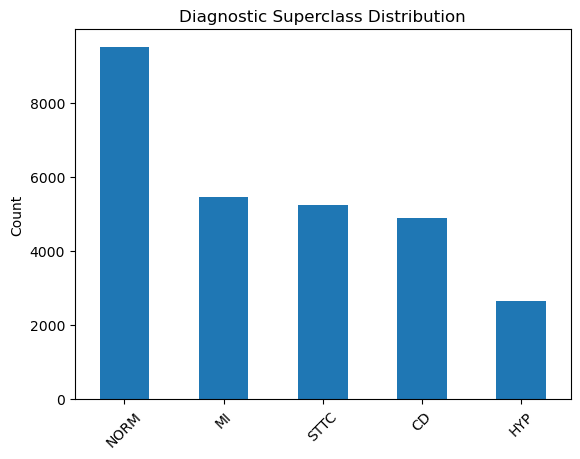

In [14]:
plt.figure()
class_counts.plot(kind="bar")
plt.title("Diagnostic Superclass Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Average labels per ECG: 1.273682279003624
Max labels per ECG: 4


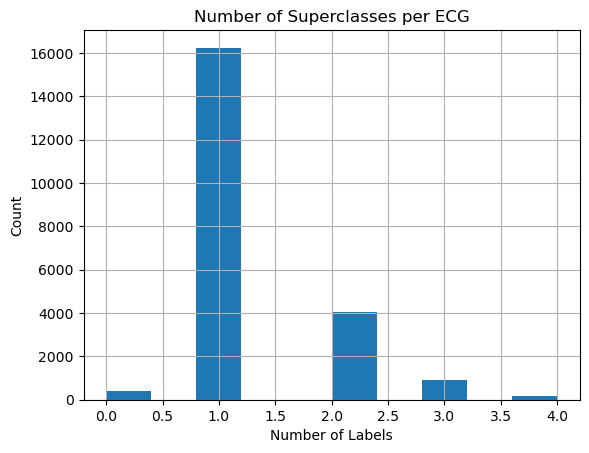

In [15]:
df["n_labels"] = df["superclasses"].apply(len)

print("Average labels per ECG:", df["n_labels"].mean())
print("Max labels per ECG:", df["n_labels"].max())

plt.figure()
df["n_labels"].hist(bins=10)
plt.title("Number of Superclasses per ECG")
plt.xlabel("Number of Labels")
plt.ylabel("Count")
plt.show()

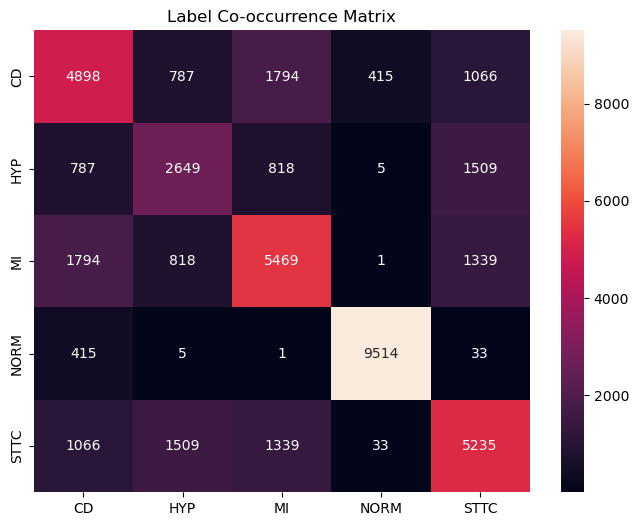

In [16]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
label_matrix = mlb.fit_transform(df["superclasses"])

co_occurrence = np.dot(label_matrix.T, label_matrix)
co_df = pd.DataFrame(co_occurrence,
                     index=mlb.classes_,
                     columns=mlb.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(co_df, annot=True, fmt="d")
plt.title("Label Co-occurrence Matrix")
plt.show()

## Generate Table 1 

In [17]:
# Flatten labels for the superclass distribution
all_classes = [cls for sublist in df["superclasses"] for cls in sublist]
class_counts = pd.Series(all_classes).value_counts()
class_percent = class_counts / n_records * 100

In [18]:
table1_rows = []

# Cohort size
table1_rows.append(["Total ECG Recordings", f"{n_records:,}"])
table1_rows.append(["Unique Patients", f"{n_patients:,}"])

# Age
table1_rows.append([
    "Age (years), mean ± SD",
    f"{age_mean:.1f} ± {age_sd:.1f}"
])

table1_rows.append([
    "Age (years), median (IQR)",
    f"{age_median:.1f} ({age_q1:.1f}–{age_q3:.1f})"
])

# Sex
for sex in sex_counts.index:
    table1_rows.append([
        f"Sex: {sex}",
        f"{sex_counts[sex]:,} ({sex_percent[sex]:.1f}%)"
    ])

# Diagnostic Superclasses
for cls in class_counts.index:
    table1_rows.append([
        f"Diagnosis: {cls}",
        f"{class_counts[cls]:,} ({class_percent[cls]:.1f}%)"
    ])

table1 = pd.DataFrame(table1_rows, columns=["Characteristic", "Value"])

table1

,Characteristic,Value
0,Total ECG Recordings,"21,799"
1,Unique Patients,"18,869"
2,"Age (years), mean ± SD",59.9 ± 17.0
3,"Age (years), median (IQR)",62.0 (50.0–72.0)
4,Sex: Male,"11,354 (52.1%)"
5,Sex: Female,"10,445 (47.9%)"
6,Diagnosis: NORM,"9,514 (43.6%)"
7,Diagnosis: MI,"5,469 (25.1%)"
8,Diagnosis: STTC,"5,235 (24.0%)"
9,Diagnosis: CD,"4,898 (22.5%)"
